# LSTM Overview

## 1. What is LSTM?

**LSTM (Long Short-Term Memory)** is a specialized type of Recurrent Neural Network (RNN) designed to work with **sequential/time-series data**.  
It can **remember past patterns for long periods** using internal memory and gates.  
### Purpose of LSTM in time-series:
- To learn trends and temporal dependencies over time.
- To forecast future values based on historical data.
- Useful for problems like air-quality prediction, weather forecasting, stock prediction, etc.





from google.colab import drive

# Monter le Drive
drive.mount('/content/drive')


In [44]:
# Import libraries here
import inspect
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import pytz
from IPython.display import VimeoVideo
from glob import glob

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.ar_model import AutoReg
from pandas import MultiIndex, Int16Dtype
import xgboost as xgb
from pandas import Timestamp
import statsmodels.api as sm
from statsmodels.graphics.api import qqplot
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
#from tensorflow.keras.utils import TimeseriesGenerator
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
import tensorflow as tf
# The following two lines are causing the RuntimeError because they disable TensorFlow 2.x behavior
# import tensorflow.compat.v1 as tf
# tf.compat.v1.disable_v2_behavior()

# sensors.AFRICA Air Quality Archive Abuja

## Dataset Info
**Source:** sensors.AFRICA / openAFRICA  

Air-quality measurements in Abuja from multiple sensors and locations, suitable for **time-series analysis and PM2.5 forecasting**.

### Key Variables
| Variable | Meaning |
|----------|---------|
| `timestamp` | Date & time |
| `sensor_id` | Sensor ID |
| `sensor_type` | Sensor type |
| `location` | Physical location |
| `lat`, `lon` | Coordinates |
| `value_type` | Parameter type |
| `value` | Measurement |
| `P0` | PM1 |
| `P2` | PM2.5 |
| `P1` | PM10 |
| `temperature` | Ambient temperature (°C) |
| `humidity` | Relative humidity (%) |

> PM1 = P0, PM2.5 = P2, PM10 = P1

## Data Format
- CSV files, each row = one sensor reading.  
- Ready for **resampling, cleaning, and LSTM modeling**.

## Use Cases
- Visualize air-quality trends.  
- Forecast PM levels with LSTM/ML.  
- Analyze daily/seasonal pollution patterns.  
- Study correlation with weather variables.  
- Detect anomalies and peaks.


In [45]:
from glob import glob

#folder_path = '/content/drive/My Drive/AIR QUALITY IN ABUJA/'
folder_path = '/home/student25/Documents/Patrick25/Deep learning and algo/tuto/Lstm/AIR QUALITY IN ABUJA-20251205T102324Z-1-001/AIR QUALITY IN ABUJA/'

files = glob(folder_path + "Sensor_Data_*")


print(files)

['/home/student25/Documents/Patrick25/Deep learning and algo/tuto/Lstm/AIR QUALITY IN ABUJA-20251205T102324Z-1-001/AIR QUALITY IN ABUJA/Sensor_Data_Dec_2022.csv', '/home/student25/Documents/Patrick25/Deep learning and algo/tuto/Lstm/AIR QUALITY IN ABUJA-20251205T102324Z-1-001/AIR QUALITY IN ABUJA/Sensor_Data_April_2023.csv', '/home/student25/Documents/Patrick25/Deep learning and algo/tuto/Lstm/AIR QUALITY IN ABUJA-20251205T102324Z-1-001/AIR QUALITY IN ABUJA/Sensor_Data_May_2023.csv', '/home/student25/Documents/Patrick25/Deep learning and algo/tuto/Lstm/AIR QUALITY IN ABUJA-20251205T102324Z-1-001/AIR QUALITY IN ABUJA/Sensor_Data_Mars_2023.csv', '/home/student25/Documents/Patrick25/Deep learning and algo/tuto/Lstm/AIR QUALITY IN ABUJA-20251205T102324Z-1-001/AIR QUALITY IN ABUJA/Sensor_Data_Fev_2023.csv', '/home/student25/Documents/Patrick25/Deep learning and algo/tuto/Lstm/AIR QUALITY IN ABUJA-20251205T102324Z-1-001/AIR QUALITY IN ABUJA/Sensor_Data_June_2023.csv', '/home/student25/Docume

### `wrangle(files, resample_rule="1D")`
Loads multiple CSV files, cleans timestamps, keeps PM2.5 readings, removes outliers, converts time to Africa/Lagos, and resamples the data (daily by default) to produce a clean time-series for analysis or modeling.


In [46]:
def wrangle(files, resample_rule="1D"):
    # Read all CSV files and concatenate
    df = pd.concat([pd.read_csv(file, sep=';') for file in files]).copy()

    # Convert timestamp to datetime, handle ISO8601 and mixed formats
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)

    # Remove rows with invalid timestamps
    df = df.dropna(subset=['timestamp'])

    # Set datetime index
    df = df.set_index('timestamp')

    # Convert UTC to Nigeria time
    df.index = df.index.tz_convert('Africa/Lagos')

    # Keep only PM2.5 readings and remove outliers (>250)
    df = df[(df["value_type"] == "P2") & (df["value"] < 250)]

    # Resample to desired interval and forward-fill missing values
    df_resampled = df["value"].resample(resample_rule).mean().fillna(method='ffill')

    return df_resampled


In [47]:
import pandas as pd
df = wrangle(files, resample_rule="1D")
print(df.shape)
df.head(10)

(213,)


timestamp
2022-12-01 00:00:00+01:00    63.518761
2022-12-02 00:00:00+01:00    75.495457
2022-12-03 00:00:00+01:00    85.614430
2022-12-04 00:00:00+01:00    86.636921
2022-12-05 00:00:00+01:00    53.554853
2022-12-06 00:00:00+01:00    52.801150
2022-12-07 00:00:00+01:00    56.317250
2022-12-08 00:00:00+01:00    56.826848
2022-12-09 00:00:00+01:00    37.821479
2022-12-10 00:00:00+01:00    51.125163
Freq: D, Name: value, dtype: float64

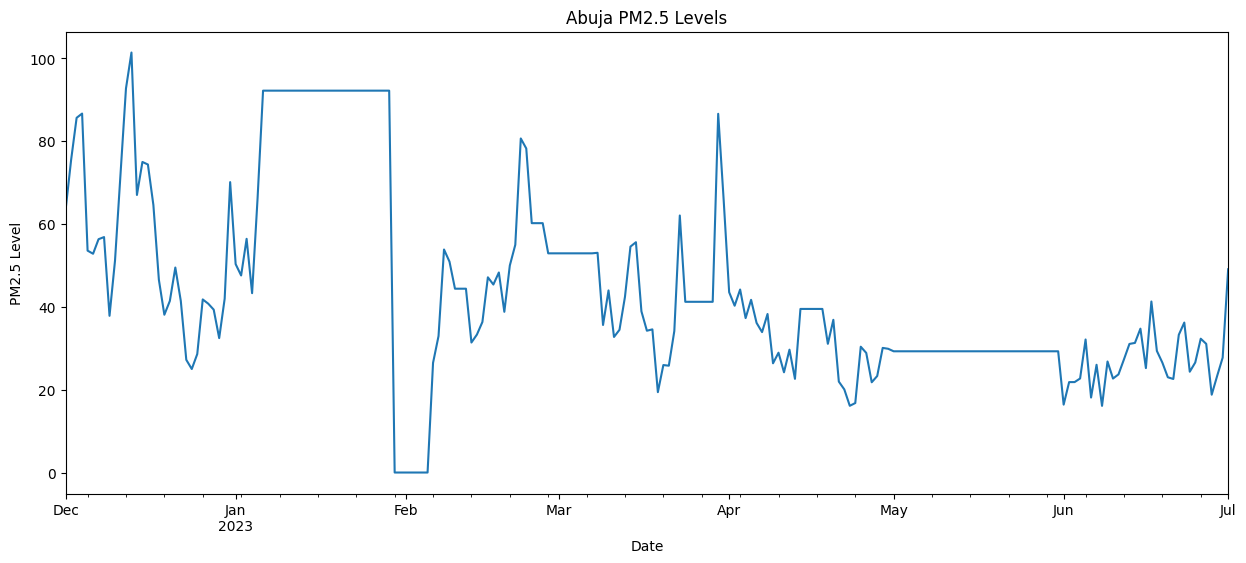

In [49]:
import os
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(15, 6))
df.plot(xlabel="Date", ylabel="PM2.5 Level", title="Abuja PM2.5 Levels", ax=ax);

# Create the directory if it doesn't exist
if not os.path.exists("images"):
    os.makedirs("images")

# Don't delete the code below 👇
plt.savefig("images/3-5-5.png", dpi=150)

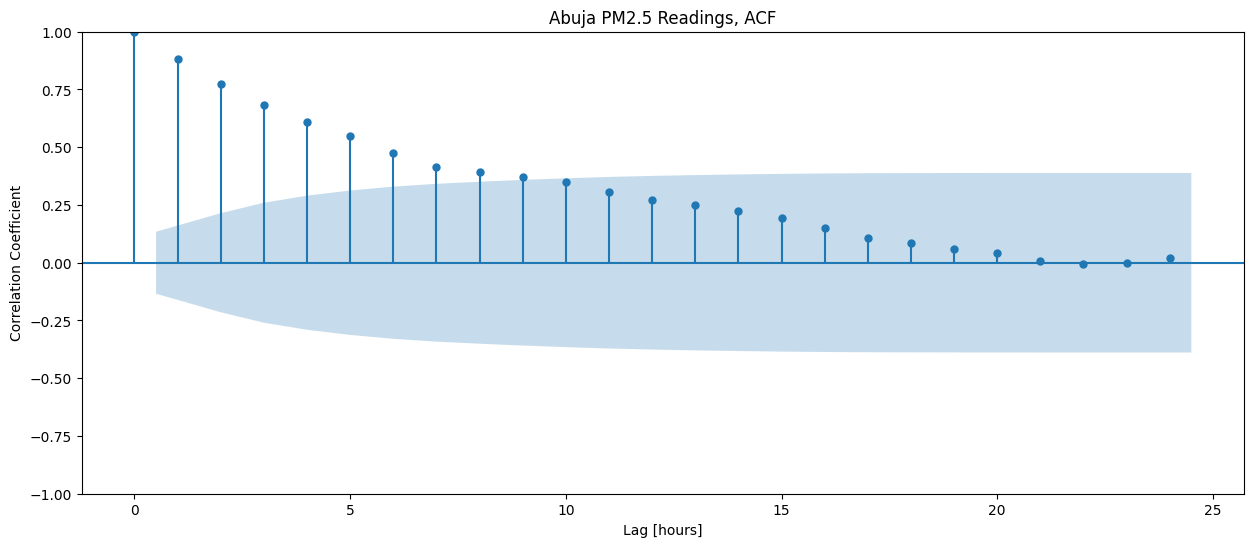

In [50]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(df, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Abuja PM2.5 Readings, ACF");
# Don't delete the code below 👇
plt.savefig("images/3-5-7.png", dpi=150)

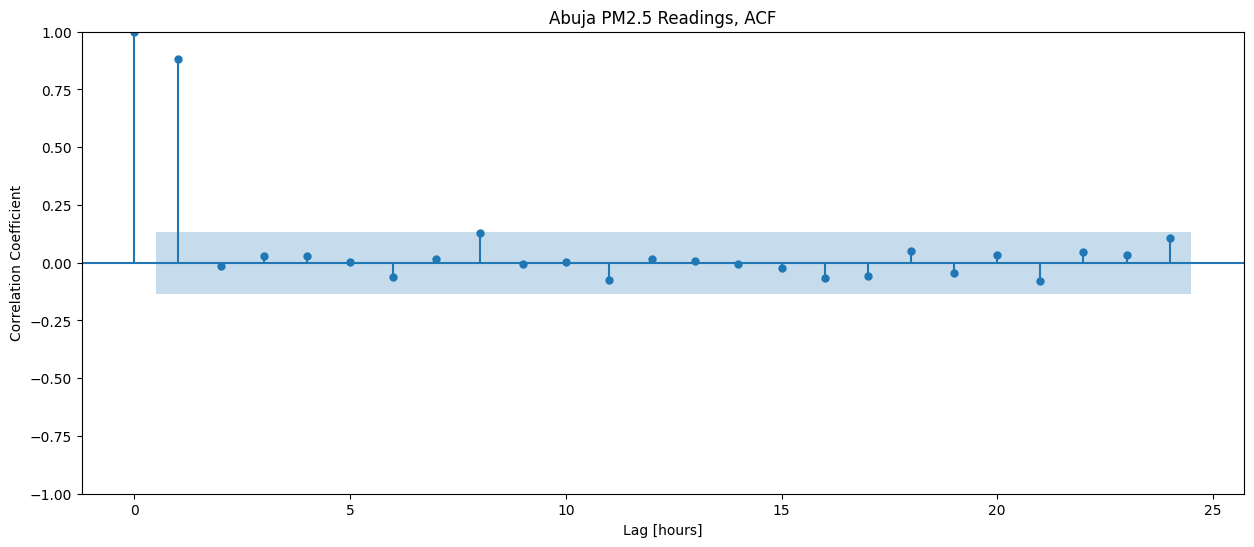

In [51]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(df, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Abuja PM2.5 Readings, ACF");
# Don't delete the code below 👇
plt.savefig("images/3-5-7.png", dpi=150)

In [52]:
# Generate corresponding dates for the time series
start_date = pd.to_datetime('2022-11-07')
date_range = pd.date_range(start_date, periods=len(df), freq='D')

In [53]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df.values.reshape(-1, 1))

In [54]:
data_scaled

array([[0.62659034],
       [0.74473626],
       [0.84455639],
       [0.8546429 ],
       [0.52829988],
       [0.52086487],
       [0.55554996],
       [0.56057696],
       [0.37309565],
       [0.50433184],
       [0.71130058],
       [0.91437156],
       [1.        ],
       [0.66086725],
       [0.73945094],
       [0.73335252],
       [0.63683021],
       [0.45903506],
       [0.37567976],
       [0.40844056],
       [0.4880306 ],
       [0.40841747],
       [0.26838415],
       [0.24643017],
       [0.28209816],
       [0.4121221 ],
       [0.40203606],
       [0.38780965],
       [0.32007247],
       [0.41394782],
       [0.69143423],
       [0.496232  ],
       [0.46917289],
       [0.55643008],
       [0.42698365],
       [0.65301462],
       [0.90920685],
       [0.90920685],
       [0.90920685],
       [0.90920685],
       [0.90920685],
       [0.90920685],
       [0.90920685],
       [0.90920685],
       [0.90920685],
       [0.90920685],
       [0.90920685],
       [0.909

In [55]:
# Define the number of previous time steps to use for prediction
look_back = 10

In [56]:
X, y = [], []
for i in range(len(data_scaled) - look_back):
    X.append(data_scaled[i : i + look_back])
    y.append(data_scaled[i + look_back])

In [13]:
X, y = np.array(X), np.array(y)
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

y_train shape: (182, 1)
y_test shape: (21, 1)
X_train shape: (182, 10, 1)
X_test shape: (21, 10, 1)


In [57]:
#Xnew=tensor.tonumpy

In [58]:
# Calculate baseline metrics
y_train_mean = y_train.mean()
y_pred_baseline = [y_train_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)
rmse_baseline = mean_squared_error(y_train, y_pred_baseline)
baseline_r2 = r2_score(y_train, y_pred_baseline)
print("Mean P2 Reading:", y_train_mean)
print("Baseline MAE:", mae_baseline)
print("Baseline RMSE:", rmse_baseline)
print("Baseline R2:", baseline_r2)

Mean P2 Reading: tensor(0.4138)
Baseline MAE: 0.1747160255908966
Baseline RMSE: 0.053245898336172104
Baseline R2: 0.0


In [59]:
import tensorflow as tf

tf.config.run_functions_eagerly(True)  # optional, forces eager mode
# or check
print(tf.executing_eagerly())  # should return True


True


In [60]:
# Create the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(look_back, 1)))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=64)

# Make predictions
y_pred = model.predict(X_test)

# # Inverse transform to get original scale
# y_test_original = scaler.inverse_transform(y_test)
# y_pred_original = scaler.inverse_transform(y_pred)

# Calculate metrics for the LSTM model
lstm_mae = mean_absolute_error(y_test, y_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lstm_r2 = r2_score(y_test, y_pred)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.2119
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1800
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1535
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1271
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1033
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0789
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0544
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0373
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0353
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0416
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0368
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0317
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0309
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0315
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0317
Epoch 16/50
3/3 ━━━━━━━━━━━━━━━━━━

In [61]:
print(f"Baseline MAE: {mae_baseline:.4f}, RMSE: {rmse_baseline:.4f}, R2: {baseline_r2:.4f}")
print(f"LSTM Model MAE: {lstm_mae:.4f}, RMSE: {lstm_rmse:.4f}, R2: {lstm_r2:.4f}")

Baseline MAE: 0.1747, RMSE: 0.0532, R2: 0.0000
LSTM Model MAE: 0.0927, RMSE: 0.1416, R2: 0.6029


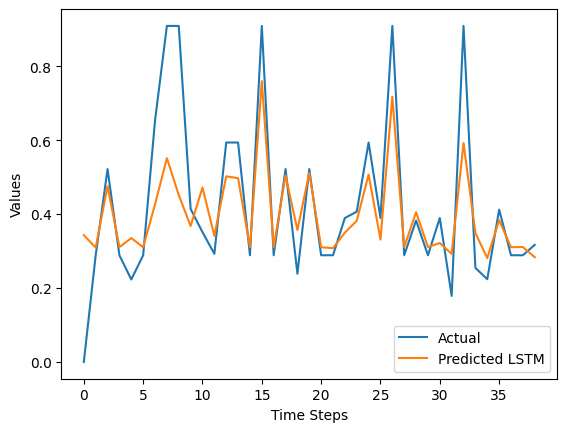

In [62]:
# Visualize the results
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted LSTM')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.legend()
plt.show()

# Using pytorch

In [63]:
import torch
from torch import nn
from sklearn.model_selection import train_test_split


SEQ_LEN = 20

def create_sequences(data_scaled, seq_len):
    xs, ys = [], []
    for i in range(len(data_scaled) - seq_len):
        xs.append(data_scaled[i:i+seq_len])
        ys.append(data_scaled[i+seq_len])
    return np.array(xs), np.array(ys)

X_np, y_np = create_sequences(data_scaled, SEQ_LEN)
X = torch.tensor(X_np, dtype=torch.float32).unsqueeze(-1)
y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)

In [64]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print shapes using .shape
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: torch.Size([154, 20, 1, 1])
X_test shape: torch.Size([39, 20, 1, 1])
y_train shape: torch.Size([154, 1, 1])
y_test shape: torch.Size([39, 1, 1])


In [65]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)  # (batch, seq_len, input_size)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)  # (batch, seq_len, input_size)

y_train = y_train.reshape(y_train.shape[0], -1)  # ensure 2D
y_test = y_test.reshape(y_test.shape[0], -1)  # ensure 2D

In [66]:
# Print shapes using .shape
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: torch.Size([154, 20, 1])
X_test shape: torch.Size([39, 20, 1])
y_train shape: torch.Size([154, 1])
y_test shape: torch.Size([39, 1])


In [67]:
# Calculate baseline metrics
y_train_mean = y_train.mean()
y_pred_baseline = [y_train_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)
rmse_baseline = mean_squared_error(y_train, y_pred_baseline)
baseline_r2 = r2_score(y_train, y_pred_baseline)
print("Mean P2 Reading:", y_train_mean)
print("Baseline MAE:", mae_baseline)
print("Baseline RMSE:", rmse_baseline)
print("Baseline R2:", baseline_r2)

Mean P2 Reading: tensor(0.4138)
Baseline MAE: 0.1747160255908966
Baseline RMSE: 0.053245898336172104
Baseline R2: 0.0


In [68]:
import tensorflow as tf

tf.config.run_functions_eagerly(True)  # optional, forces eager mode
# or check
print(tf.executing_eagerly())  # should return True

True


In [69]:
# Create the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(look_back, 1)))
model_lstm.add(Dense(1))

# Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model_lstm.fit(X_train, y_train, epochs=50, batch_size=64)

# Make predictions
y_pred = model_lstm.predict(X_test)

# # Inverse transform to get original scale
# y_test_original = scaler.inverse_transform(y_test)
# y_pred_original = scaler.inverse_transform(y_pred)

# Calculate metrics for the LSTM model
lstm_mae = mean_absolute_error(y_test, y_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lstm_r2 = r2_score(y_test, y_pred)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.1979
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.1721
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1480
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.1222
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0951
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0681
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0463
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0329
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0365
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0371
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0308
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0290
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0295
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0292
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0281
Epoch 16/50
3/3 ━━━━━━━━━━━━━━━━━━

In [70]:
print(f"Baseline MAE: {mae_baseline:.4f}, RMSE: {rmse_baseline:.4f}, R2: {baseline_r2:.4f}")
print(f"LSTM Model MAE: {lstm_mae:.4f}, RMSE: {lstm_rmse:.4f}, R2: {lstm_r2:.4f}")

Baseline MAE: 0.1747, RMSE: 0.0532, R2: 0.0000
LSTM Model MAE: 0.0625, RMSE: 0.1015, R2: 0.7961


In [71]:
class RNNRegressor(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h = self.rnn(x)
        return self.fc(h.squeeze(0))

model = RNNRegressor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

import torch
import torch.nn as nn

class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=50):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h = self.rnn(x)
        out = self.fc(out[:, -1, :])  # last time step
        return out

model = SimpleRNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

In [72]:
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    
    optimizer.zero_grad()
    
    # Forward pass
    preds = model(X_train)  # X_train must be 3D: (batch, seq_len, input_size)
    
    # Compute loss
    loss = criterion(preds, y_train)
    
    # Backward pass
    loss.backward()
    
    # Update weights
    optimizer.step()
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.4f}")

Epoch 1/20, Loss: 0.2625
Epoch 2/20, Loss: 0.1431
Epoch 3/20, Loss: 0.0701
Epoch 4/20, Loss: 0.0553
Epoch 5/20, Loss: 0.0821
Epoch 6/20, Loss: 0.0814
Epoch 7/20, Loss: 0.0632
Epoch 8/20, Loss: 0.0497
Epoch 9/20, Loss: 0.0460
Epoch 10/20, Loss: 0.0481
Epoch 11/20, Loss: 0.0512
Epoch 12/20, Loss: 0.0528
Epoch 13/20, Loss: 0.0520
Epoch 14/20, Loss: 0.0495
Epoch 15/20, Loss: 0.0460
Epoch 16/20, Loss: 0.0424
Epoch 17/20, Loss: 0.0395
Epoch 18/20, Loss: 0.0379
Epoch 19/20, Loss: 0.0375
Epoch 20/20, Loss: 0.0378


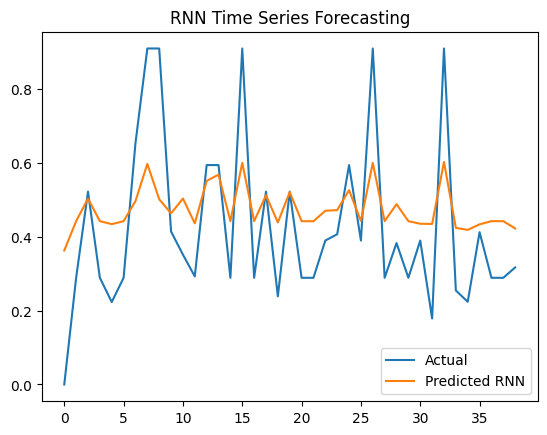

In [73]:
model.eval()
with torch.no_grad():
    preds = model(X_test).numpy()
plt.plot(y_test, label="Actual")
plt.plot(preds, label="Predicted RNN")
plt.legend()
plt.title("RNN Time Series Forecasting")
plt.show()

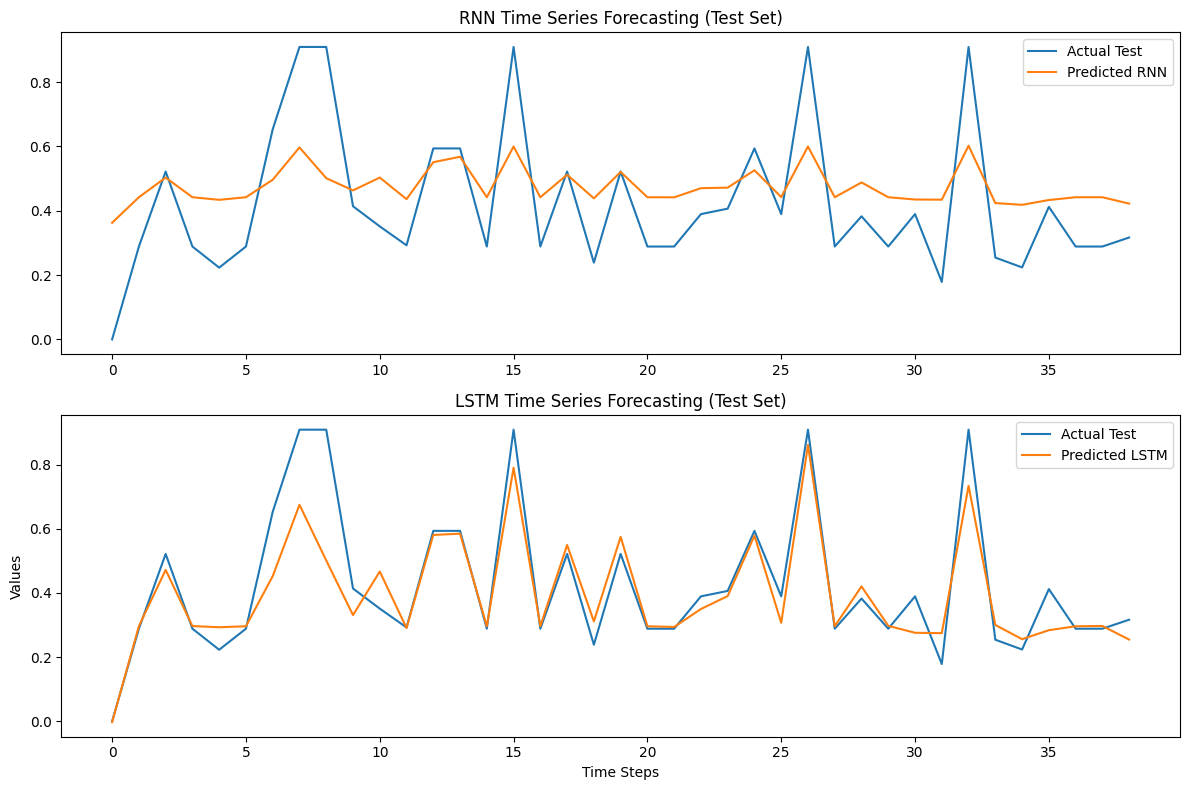

In [74]:
import matplotlib.pyplot as plt
import torch

# ----- RNN TRAIN PREDICTIONS -----
model.eval()
with torch.no_grad():
    preds_test = model(X_test).detach().numpy()

# ----- YOUR LSTM TEST PREDICTIONS -----
# y_pred already computed from Keras LSTM as a NumPy array

# ----- PLOT EVERYTHING TOGETHER -----
plt.figure(figsize=(12, 8))

# --- subplot 1: RNN ---
plt.subplot(2, 1, 1)
plt.plot(y_test, label="Actual Test")
plt.plot(preds_test, label="Predicted RNN")
plt.legend()
plt.title("RNN Time Series Forecasting (Test Set)")

# --- subplot 2: LSTM ---
plt.subplot(2, 1, 2)
plt.plot(y_test, label="Actual Test")
plt.plot(y_pred, label="Predicted LSTM")
plt.xlabel("Time Steps")
plt.ylabel("Values")
plt.legend()
plt.title("LSTM Time Series Forecasting (Test Set)")

plt.tight_layout()
plt.show()
